# CF distance as a confidence score

For each query the C2 pipeline retrieved a counterfactual (nearest opposite-prediction, correctly-classified training image). Here we recover **how far** that counterfactual was, measured in exactly the space the retrieval minimised over: the fold's standardised attribute space, scaler fit on the fold's train rows.

Two questions:
1. How does the distance vary between diseases?
2. Used as a confidence score, how well does it predict C0 error (AUC)?

Sign convention: a query close to an opposite-prediction neighbour sits near the decision boundary, so **small distance should mean likely error**. AUC therefore scores errors with `-distance`.

In [1]:
import sys, os
sys.path.insert(0, 'code')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import c2_cf_distance as D
import c2_folds as F

DISEASES = D.DISEASES
DISEASES

['effusion', 'cardiomegaly', 'consolidation', 'edema', 'atelectasis']

## 1. Compute the distances

~3 min per disease (each fold refits that fold's scaler over the full attribute table). Cached to CSV so everything below re-runs cheaply.

In [2]:
# %%
DISTANCES = ('l1', 'l2', 'cosine')
allf_by_distance = {m: [] for m in DISTANCES}

for d in tqdm(DISEASES):
    caches = {m: f'results/cf_distance_{m}_{d}.csv' for m in DISTANCES}

    if all(os.path.exists(c) for c in caches.values()):
        for m in DISTANCES:
            allf_by_distance[m].append(pd.read_csv(caches[m]))
    else:
        per_metric = D.cf_distances_all_metrics(d, distances=DISTANCES) 
        for m in DISTANCES:
            per_metric[m].to_csv(caches[m], index=False)
            allf_by_distance[m].append(per_metric[m])

allf_by_distance = {m: pd.concat(dfs, ignore_index=True) for m, dfs in allf_by_distance.items()}
allf_by_distance

100%|██████████| 5/5 [13:23<00:00, 160.60s/it]


{'l1':         fold                                               path     cf_dist  \
 0          0  CheXpert-v1.0-small/train/patient00002/study1/...  268.720474   
 1          0  CheXpert-v1.0-small/train/patient00005/study1/...  195.770773   
 2          0  CheXpert-v1.0-small/train/patient00005/study2/...  198.421851   
 3          0  CheXpert-v1.0-small/train/patient00005/study2/...  185.724815   
 4          0  CheXpert-v1.0-small/train/patient00014/study1/...  179.526895   
 ...      ...                                                ...         ...   
 437914     4  CheXpert-v1.0-small/train/patient64476/study1/...  183.489200   
 437915     4  CheXpert-v1.0-small/train/patient64494/study1/...  179.284333   
 437916     4  CheXpert-v1.0-small/train/patient64507/study1/...  236.296265   
 437917     4  CheXpert-v1.0-small/train/patient64520/study1/...  159.741554   
 437918     4  CheXpert-v1.0-small/train/patient64532/study1/...  269.006899   
 
         correct  effusion_prob 

## 2. How does the distance vary between diseases?

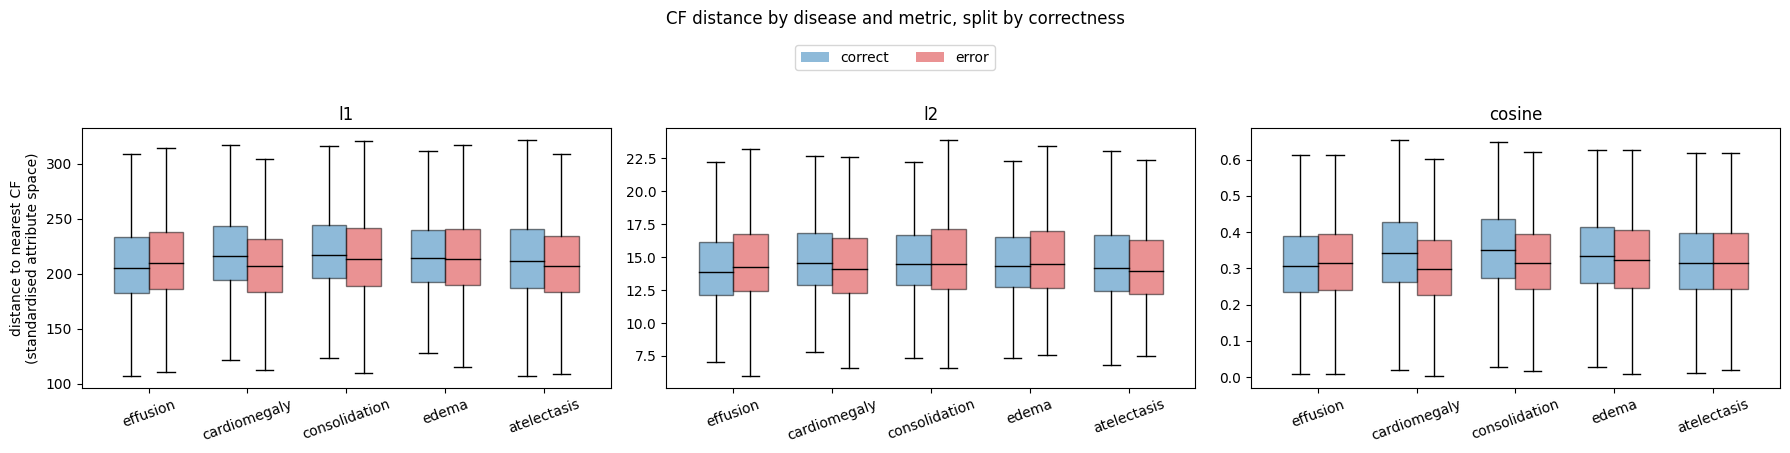

In [6]:
fig, axes = plt.subplots(1, len(DISTANCES), figsize=(6 * len(DISTANCES), 4), sharex=True)

positions = np.arange(len(DISEASES))
width = 0.35

for ax, m in zip(axes, DISTANCES):
    df = allf_by_distance[m]
    for offset, err, lab, c in [(-width/2, 0, 'correct', 'tab:blue'),
                                  (width/2, 1, 'error', 'tab:red')]:
        data = [df.loc[(df.disease == d) & (df.error == err), 'cf_dist'].clip(
                    upper=df.loc[df.disease == d, 'cf_dist'].quantile(.99))
                for d in DISEASES]
        bp = ax.boxplot(data, positions=positions + offset, widths=width,
                         showfliers=False, patch_artist=True,
                         boxprops=dict(facecolor=c, alpha=.5),
                         medianprops=dict(color='black'))
    ax.set_xticks(positions)
    ax.set_xticklabels(DISEASES)
    ax.set_title(f'{m}')
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylabel('distance to nearest CF\n(standardised attribute space)')

# one shared legend, built from proxy patches since boxplot doesn't auto-label
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='tab:blue', alpha=.5, label='correct'),
                     Patch(facecolor='tab:red', alpha=.5, label='error')],
           loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

fig.suptitle('CF distance by disease and metric, split by correctness', y=1.12)
plt.tight_layout()

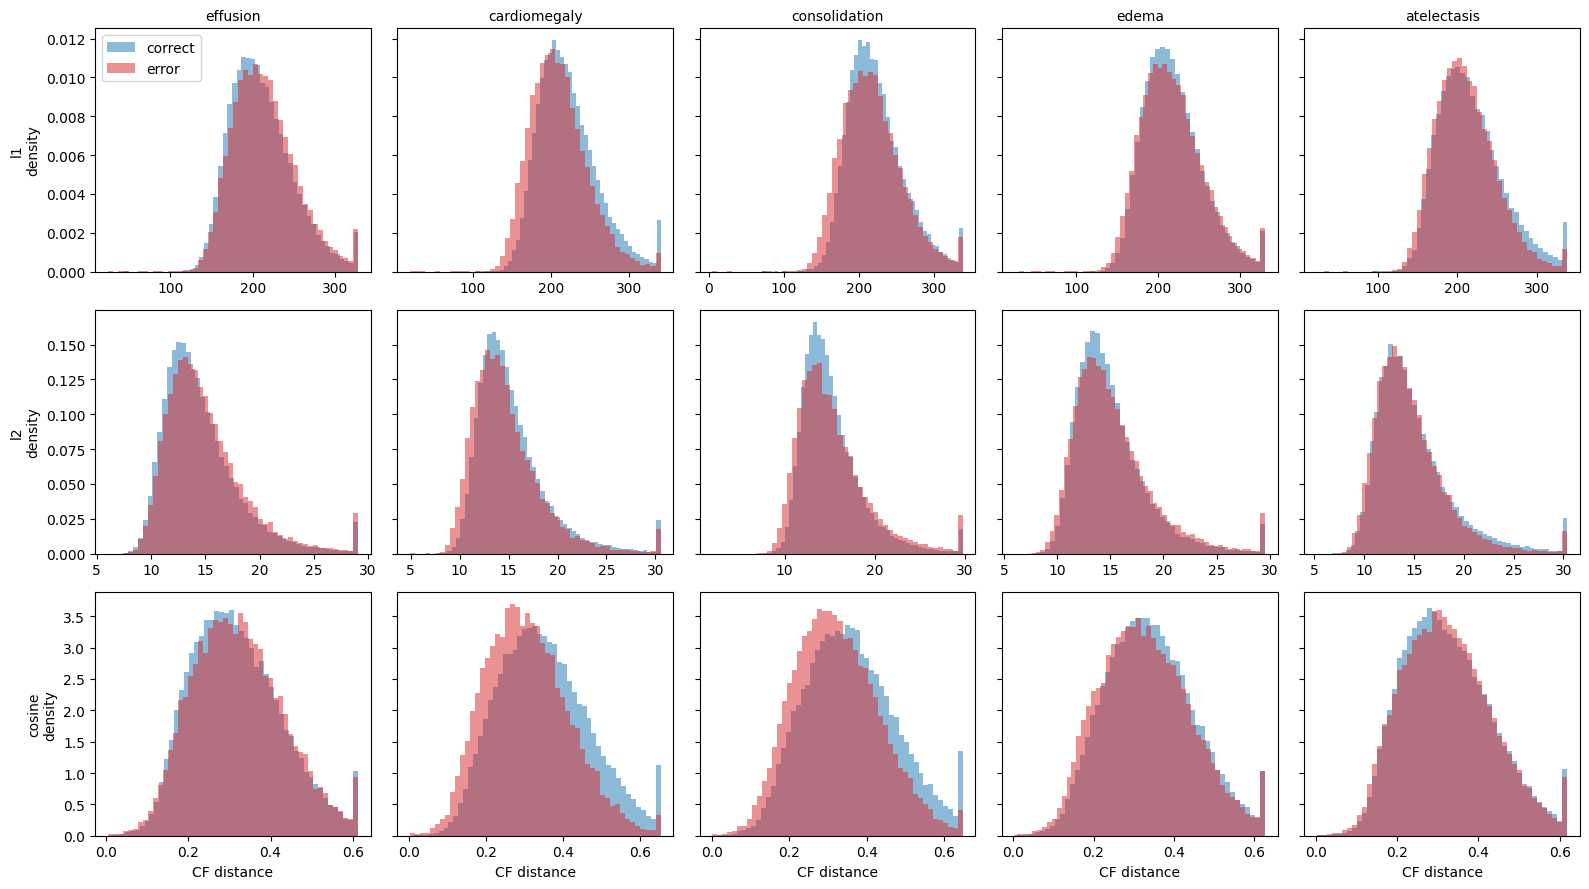

In [5]:
fig, axes = plt.subplots(len(DISTANCES), len(DISEASES), figsize=(16, 3 * len(DISTANCES)), sharey='row')

for row, m in zip(axes, DISTANCES):
    df = allf_by_distance[m]
    for ax, d in zip(row, DISEASES):
        sub = df[df.disease == d]
        hi = sub.cf_dist.quantile(.99)
        for err, lab, c in [(0, 'correct', 'tab:blue'), (1, 'error', 'tab:red')]:
            ax.hist(sub.loc[sub.error == err, 'cf_dist'].clip(upper=hi),
                    bins=50, density=True, alpha=.5, label=lab, color=c)
        ax.set_title(d if m == DISTANCES[0] else '', fontsize=10)
        if m == DISTANCES[-1]:
            ax.set_xlabel('CF distance')

for row, m in zip(axes, DISTANCES):
    row[0].set_ylabel(f'{m}\ndensity')
axes[0, 0].legend()
plt.tight_layout()

## 3. Distance as a confidence score: AUC for error prediction

`auc_cf_dist` scores errors with `-cf_dist`. `auc_msp` is the standard maximum-softmax-probability confidence baseline on the same rows.

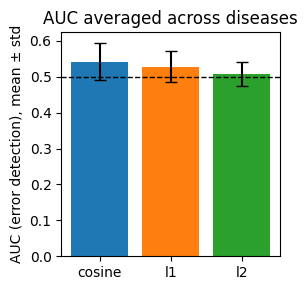

In [14]:
rows = []
for m in DISTANCES:
    df = allf_by_distance[m]
    for d in DISEASES:
        sub = df[df.disease == d]
        rows.append({'metric': m, 'disease': d,
                     'auc': roc_auc_score(sub.error, -sub.cf_dist)})
auc_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(3, 3))
summary = auc_df.groupby('metric')['auc'].agg(['mean', 'std'])
ax.bar(summary.index, summary['mean'], yerr=summary['std'], capsize=4,
       color=['tab:blue', 'tab:orange', 'tab:green'])
ax.axhline(.5, color='k', ls='--', lw=1, label='chance')
ax.set_ylabel('AUC (error detection), mean ± std')
ax.set_title('AUC averaged across diseases')
plt.tight_layout()

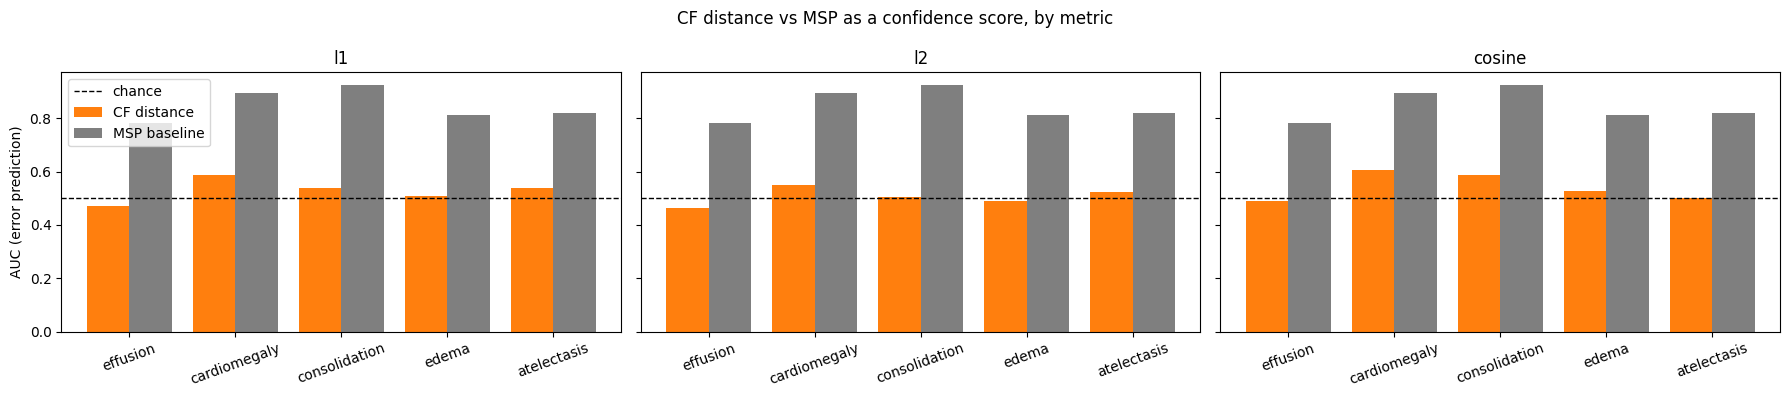

In [10]:
rows = []
for d in DISEASES:
    p = None
    for m in DISTANCES:
        sub = allf_by_distance[m][allf_by_distance[m].disease == d]
        if p is None:
            p = sub[f'{d}_prob'].values
            msp_auc_val = roc_auc_score(sub.error, -np.maximum(p, 1 - p))
        rows.append({
            'disease': d,
            'metric': m,
            'auc_cf_dist': roc_auc_score(sub.error, -sub.cf_dist),
            'auc_msp': msp_auc_val,
        })
summary = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(DISTANCES), figsize=(6 * len(DISTANCES), 4), sharey=True)

for ax, m in zip(axes, DISTANCES):
    sub = summary[summary.metric == m]
    x = np.arange(len(sub))
    ax.bar(x - .2, sub.auc_cf_dist, .4, label='CF distance', color='tab:orange')
    ax.bar(x + .2, sub.auc_msp, .4, label='MSP baseline', color='tab:grey')
    ax.axhline(.5, color='k', ls='--', lw=1, label='chance')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.disease, rotation=20)
    ax.set_title(m)

axes[0].set_ylabel('AUC (error prediction)')
axes[0].legend()
fig.suptitle('CF distance vs MSP as a confidence score, by metric')
plt.tight_layout()